In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Student Depression Dataset.csv')
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

numeric_summary = []
categorical_summary = []

# Phân tích từng cột trong DataFrame
for col in df.columns:
    data = df[col].dropna()
    unique_vals = data.unique()
    dtype = df[col].dtype

    if np.issubdtype(dtype, np.number):
        numeric_summary.append({
            "Thuộc tính": col,
            "Kiểu dữ liệu": "Số",
            "Mean": round(data.mean(), 2),
            "Median": round(data.median(), 2),
            "Midrange": round((data.min() + data.max()) / 2, 2),
            "Mode": data.mode().iloc[0] if not data.mode().empty else None,
            "Min": data.min(),
            "Max": data.max(),
            "Q1": data.quantile(0.25),
            "Q3": data.quantile(0.75)
        })
    else:
        # Nếu là kiểu rời rạc / nhị phân
        counts = data.value_counts()
        percents = (counts / len(data) * 100).round(2)
        mode = data.mode().iloc[0] if not data.mode().empty else None
        categorical_summary.append({
            "Thuộc tính": col,
            "Kiểu dữ liệu": "Rời rạc / Nhị phân",
            "Giá trị duy nhất": list(unique_vals),
            "Tần suất": counts.to_dict(),
            "Tỷ lệ (%)": percents.to_dict(),
            "Mode": mode
        })

df_numeric = pd.DataFrame(numeric_summary)
df_categorical = pd.DataFrame(categorical_summary)

# Hiển thị bảng kiểu số
print("=== THUỘC TÍNH KIỂU SỐ ===")
display(HTML(df_numeric.to_html(index=False)))


=== THUỘC TÍNH KIỂU SỐ ===


Thuộc tính,Kiểu dữ liệu,Mean,Median,Midrange,Mode,Min,Max,Q1,Q3
id,Số,70442.15,70684.00,70350.5,2.00,2.0,140699.0,35039.00,105818.00
Age,Số,25.82,25.00,38.5,24.00,18.0,59.0,21.00,30.00
Academic Pressure,Số,3.14,3.00,2.5,3.00,0.0,5.0,2.00,4.00
Work Pressure,Số,0.00,0.00,2.5,0.00,0.0,5.0,0.00,0.00
CGPA,Số,7.66,7.77,5.0,8.04,0.0,10.0,6.29,8.92
Study Satisfaction,Số,2.94,3.00,2.5,4.00,0.0,5.0,2.00,4.00
Job Satisfaction,Số,0.00,0.00,2.0,0.00,0.0,4.0,0.00,0.00
Work/Study Hours,Số,7.16,8.00,6.0,10.00,0.0,12.0,4.00,10.00
Financial Stress,Số,3.14,3.00,3.0,5.00,1.0,5.0,2.00,4.00
Depression,Số,0.59,1.00,0.5,1.00,0.0,1.0,0.00,1.00


In [ ]:
import pandas as pd
import numpy as np

# Xác định các cột rời rạc / nhị phân
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' or df[col].nunique() < 10]

# Hàm thống kê từng thuộc tính
def summarize_categorical(column):
    counts = df[column].value_counts()
    total = counts.sum()
    percentages = np.round(counts.values / total * 100, 1)
    summary_df = pd.DataFrame({
        "Thuộc tính": column,
        "Tên giá trị": counts.index,
        "Số lượng": counts.values,
        "Tỷ lệ": [f"{p}%" for p in percentages],
        "Tỷ lệ số": percentages
    })
    return summary_df

# Gộp bảng thống kê
summary_all = pd.concat([summarize_categorical(col) for col in categorical_cols], ignore_index=True)

# Lấy 4 giá trị có tỷ lệ cao nhất của mỗi thuộc tính
top4_per_field = (
    summary_all
    .sort_values(by=["Thuộc tính", "Tỷ lệ số"], ascending=[True, False])
    .groupby("Thuộc tính")
    .head(4)
    .drop(columns=["Tỷ lệ số"])  # Bỏ cột phụ
)

# Xuất ra file CSV
# Hiển thị 20 dòng đầu
print(top4_per_field.head(20))


                           Thuộc tính  Tên giá trị  Số lượng  Tỷ lệ
68                  Academic Pressure          3.0      7462  26.7%
69                  Academic Pressure          5.0      6296  22.6%
70                  Academic Pressure          4.0      5155  18.5%
71                  Academic Pressure          1.0      4801  17.2%
2                                City       Kalyan      1570   5.6%
3                                City     Srinagar      1372   4.9%
4                                City    Hyderabad      1340   4.8%
5                                City  Vasai-Virar      1290   4.6%
97                             Degree     Class 12      6080  21.8%
98                             Degree         B.Ed      1867   6.7%
99                             Degree        B.Com      1506   5.4%
100                            Degree       B.Arch      1478   5.3%
134                        Depression            1     16336  58.5%
135                        Depression           

In [ ]:
df.dtypes

,0
id,int64
Gender,object
Age,float64
City,object
Profession,object
Academic Pressure,float64
Work Pressure,float64
CGPA,float64
Study Satisfaction,float64
Job Satisfaction,float64


Tiền xử lý


In [ ]:
df.isnull().values.sum()

np.int64(3)

In [ ]:
unique_counts = df.nunique()
print( unique_counts)

id                                       27901
Gender                                       2
Age                                         34
City                                        52
Profession                                  14
Academic Pressure                            6
Work Pressure                                3
CGPA                                       332
Study Satisfaction                           6
Job Satisfaction                             5
Sleep Duration                               5
Dietary Habits                               4
Degree                                      28
Have you ever had suicidal thoughts ?        2
Work/Study Hours                            13
Financial Stress                             5
Family History of Mental Illness             2
Depression                                   2
dtype: int64


In [ ]:
unique_counts = df.nunique()

print("Số lượng giá trị unique của từng cột:")
print(unique_counts)


Số lượng giá trị unique của từng cột:
id                                       27901
Gender                                       2
Age                                         34
City                                        52
Profession                                  14
Academic Pressure                            6
Work Pressure                                3
CGPA                                       332
Study Satisfaction                           6
Job Satisfaction                             5
Sleep Duration                               5
Dietary Habits                               4
Degree                                      28
Have you ever had suicidal thoughts ?        2
Work/Study Hours                            13
Financial Stress                             5
Family History of Mental Illness             2
Depression                                   2
dtype: int64


In [ ]:
total_unique_values = unique_counts.sum()
print("\nTổng số unique trong toàn bộ dataset:", total_unique_values)


Tổng số unique trong toàn bộ dataset: 28416


In [ ]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [ ]:
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


2.1.1

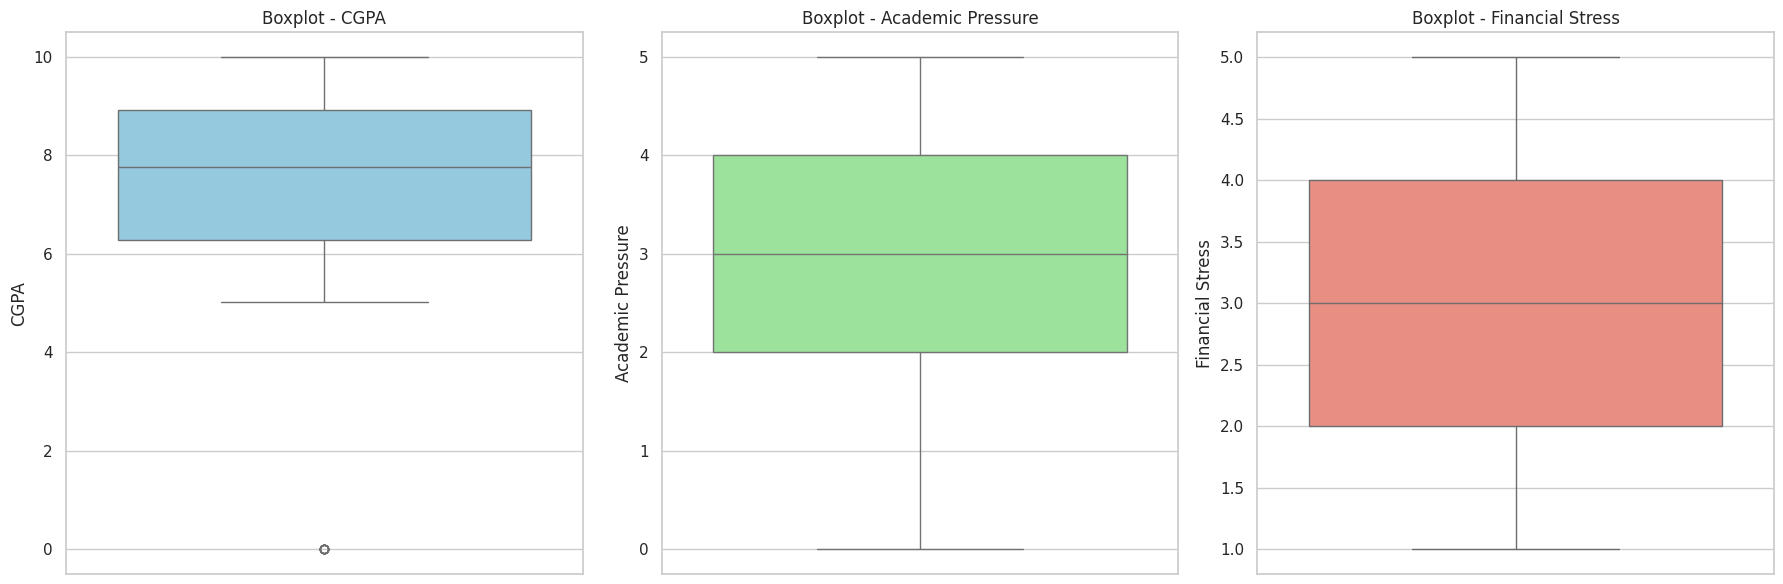

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
selected_columns = ['CGPA', 'Academic Pressure', 'Financial Stress']
df_selected = df[selected_columns].dropna()
sns.set(style="whitegrid")
# ========== BOX PLOTS ==========
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_selected['CGPA'], color='skyblue')
plt.title('Boxplot - CGPA')
plt.subplot(1, 3, 2)
sns.boxplot(y=df_selected['Academic Pressure'], color='lightgreen')
plt.title('Boxplot - Academic Pressure')
plt.subplot(1, 3, 3)
sns.boxplot(y=df_selected['Financial Stress'], color='salmon')
plt.title('Boxplot - Financial Stress')
plt.tight_layout()
plt.show()


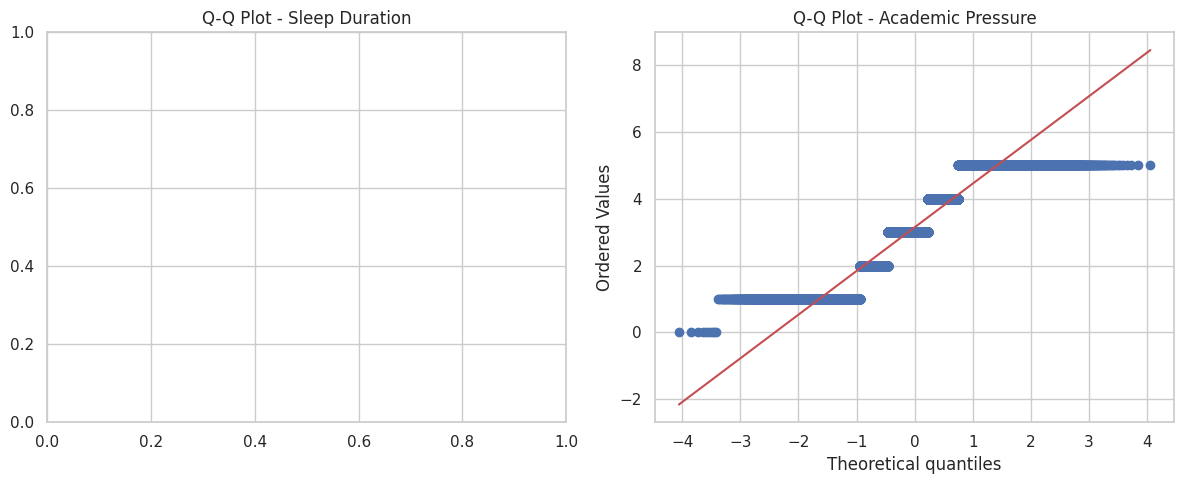

In [ ]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

df['Sleep Duration'] = pd.to_numeric(df['Sleep Duration'], errors='coerce')

sleep_duration_data = df['Sleep Duration'].dropna()

plt.figure(figsize=(12, 5))

# Q-Q plot: Sleep Duration
plt.subplot(1, 2, 1)
stats.probplot(sleep_duration_data, dist="norm", plot=plt)
plt.title('Q-Q Plot - Sleep Duration')

# Q-Q plot: Academic Pressure
plt.subplot(1, 2, 2)
stats.probplot(df['Academic Pressure'], dist="norm", plot=plt)  # Assuming 'Academic Pressure' is numeric
plt.title('Q-Q Plot - Academic Pressure')

plt.tight_layout()
plt.show()

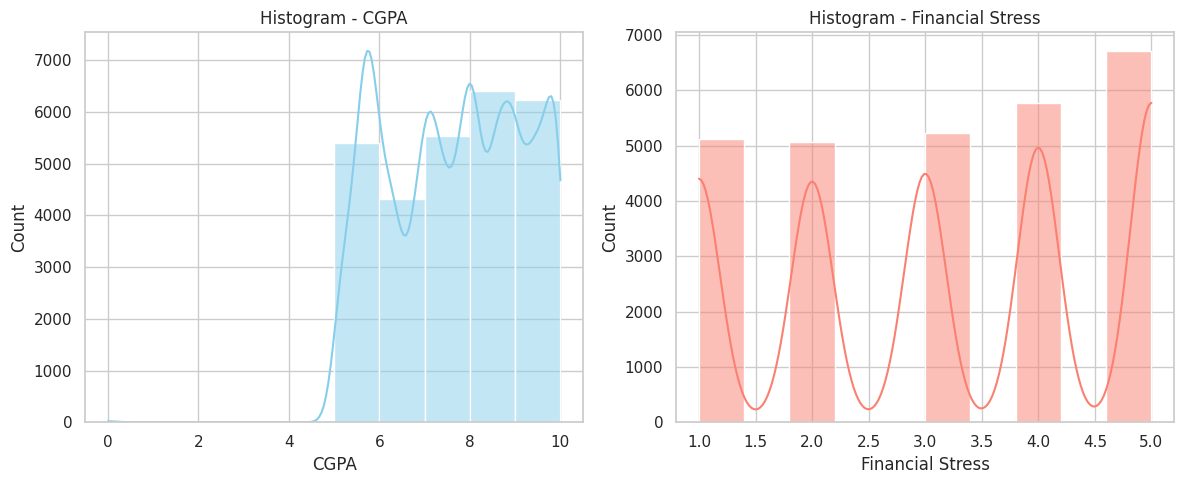

In [ ]:
# ========== HISTOGRAMS ==========
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_selected['CGPA'], kde=True, color='skyblue', bins=10)
plt.title('Histogram - CGPA')

plt.subplot(1, 2, 2)
sns.histplot(df_selected['Financial Stress'], kde=True, color='salmon', bins=10)
plt.title('Histogram - Financial Stress')

plt.tight_layout()
plt.show()

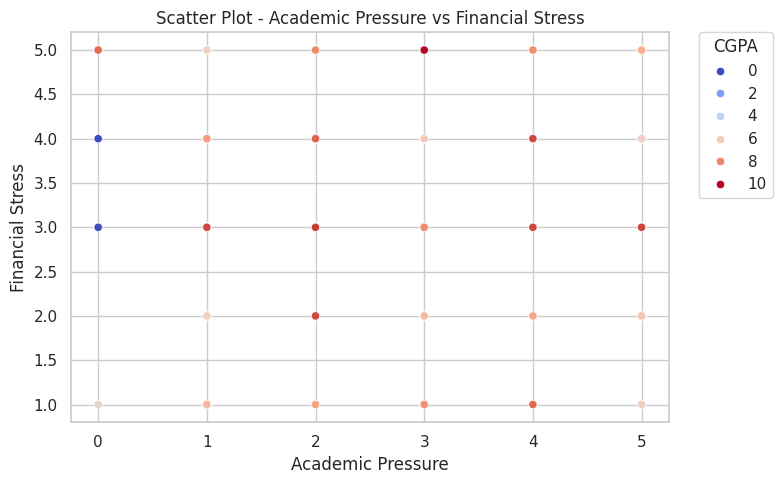

In [ ]:
# ========== SCATTER PLOT ==========
plt.figure(figsize=(8, 5))
scatter = sns.scatterplot(
    data=df_selected,
    x='Academic Pressure',
    y='Financial Stress',
    hue='CGPA',
    palette='coolwarm'
)
plt.title('Scatter Plot - Academic Pressure vs Financial Stress')

plt.legend(
    title='CGPA',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()


2.1.2

/tmp/ipython-input-598603394.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped, x='City', y='CGPA', palette='Set2')


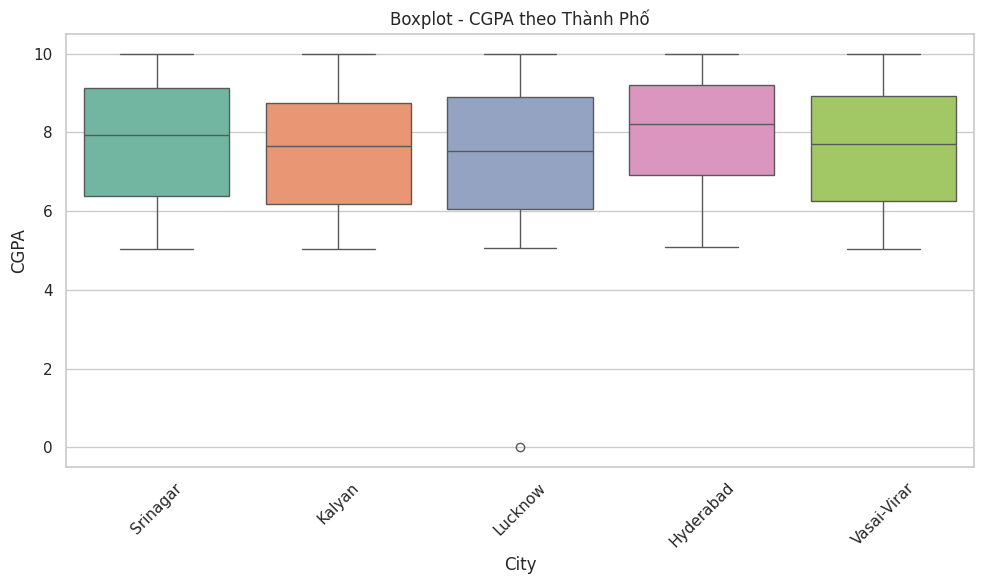

In [ ]:
df_grouped = df[['City', 'CGPA', 'Academic Pressure']].dropna()

# Lấy top 5 thành phố có số lượng sinh viên lớn nhất để trực quan rõ ràng hơn
top_cities = df_grouped['City'].value_counts().head(5).index
df_grouped = df_grouped[df_grouped['City'].isin(top_cities)]

# ========== BOXPLOT: CGPA theo City ==========
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_grouped, x='City', y='CGPA', palette='Set2')
plt.title('Boxplot - CGPA theo Thành Phố')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


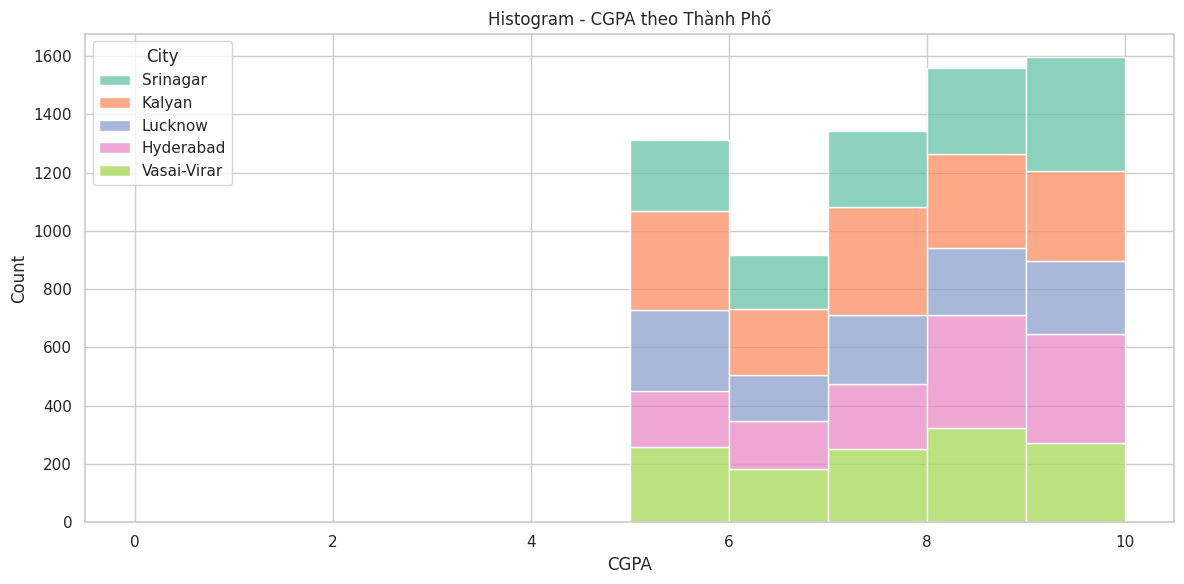

In [ ]:
# ========== HISTOGRAM: CGPA theo City ==========
plt.figure(figsize=(12, 6))
sns.histplot(data=df_grouped, x='CGPA', hue='City', multiple='stack', palette='Set2', bins=10)
plt.title('Histogram - CGPA theo Thành Phố')
plt.tight_layout()
plt.show()

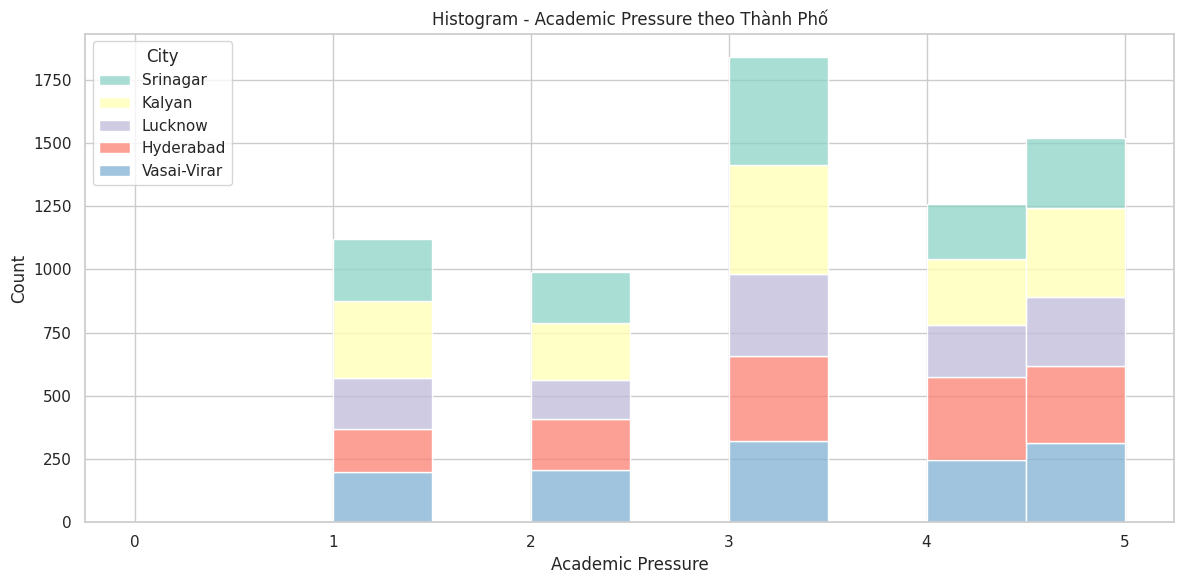

In [ ]:
# ========== HISTOGRAM: Academic Pressure theo City ==========
plt.figure(figsize=(12, 6))
sns.histplot(data=df_grouped, x='Academic Pressure', hue='City', multiple='stack', palette='Set3', bins=10)
plt.title('Histogram - Academic Pressure theo Thành Phố')
plt.tight_layout()
plt.show()

2.1.3

In [ ]:
import pandas as pd

df = pd.read_csv("Student Depression Dataset.csv")
print(df.columns.tolist())


['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


Các cột trong DataFrame:
['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
Dữ liệu sau mã hóa:
    Gender   Age  CGPA  Degree
0       1  33.0  8.97       0
1       0  24.0  5.90       3
2       1  31.0  7.03       1
3       0  28.0  5.59       2

=== Ma trận tương quan ===
           Gender       Age      CGPA    Degree
Gender  1.000000  0.884652  0.851406 -0.894427
Age     0.884652  1.000000  0.826680 -0.989071
CGPA    0.851406  0.826680  1.000000 -0.899134
Degree -0.894427 -0.989071 -0.899134  1.000000


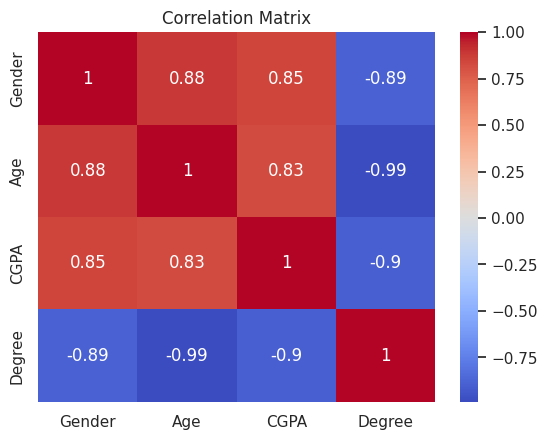


=== Độ đo Cosine (Cosine Similarity) giữa các dòng ===
           0         1         2         3
0  1.000000  0.991995  0.998606  0.994801
1  0.991995  1.000000  0.995358  0.997748
2  0.998606  0.995358  1.000000  0.998430
3  0.994801  0.997748  0.998430  1.000000


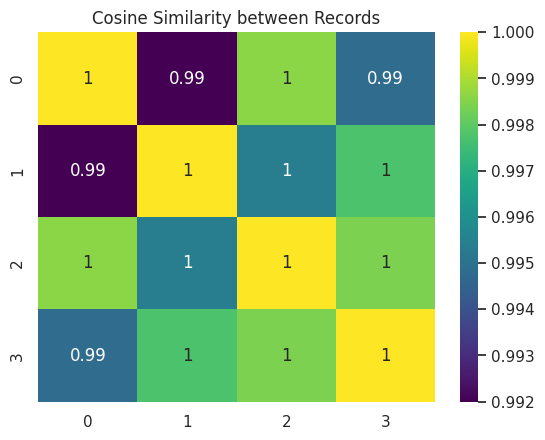

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

print("Các cột trong DataFrame:")
print(df.columns.tolist())

selected_columns = ['Gender', 'Age', 'CGPA', 'Degree'] # UPDATE THIS LINE

# Select columns from the original dataframe
df_selected = df[selected_columns].head(4).copy()

# Mã hóa dữ liệu danh nghĩa / thứ tự
le = LabelEncoder()
for col in df_selected.columns:
    if df_selected[col].dtype == 'object':
        df_selected[col] = le.fit_transform(df_selected[col])

# Hiển thị dữ liệu đã mã hóa
print("Dữ liệu sau mã hóa:\n", df_selected)

#  Ma trận tương quan
corr_matrix = df_selected.corr()
print("\n=== Ma trận tương quan ===\n", corr_matrix)

# Vẽ biểu đồ heatmap tương quan
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#  Cosine Similarity
cos_sim = cosine_similarity(df_selected)
cos_sim_df = pd.DataFrame(cos_sim, index=df_selected.index, columns=df_selected.index)
print("\n=== Độ đo Cosine (Cosine Similarity) giữa các dòng ===\n", cos_sim_df)

# Vẽ biểu đồ cosine similarity
sns.heatmap(cos_sim_df, annot=True, cmap='viridis')
plt.title("Cosine Similarity between Records")
plt.show()

In [ ]:
df = pd.DataFrame(df)
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
df.fillna(0, inplace=True)
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
print('số lượng hàng có trong df l:', len(df.axes[0]))
print('số lượng cột có trong df l:', len(df.axes[1]))

số lượng hàng có trong df l: 27901
số lượng cột có trong df l: 18


In [ ]:
for i, col in enumerate(df.columns):
  print(f'Cột {i + 1}', col)

Cột 1 id
Cột 2 Gender
Cột 3 Age
Cột 4 City
Cột 5 Profession
Cột 6 Academic Pressure
Cột 7 Work Pressure
Cột 8 CGPA
Cột 9 Study Satisfaction
Cột 10 Job Satisfaction
Cột 11 Sleep Duration
Cột 12 Dietary Habits
Cột 13 Degree
Cột 14 Have you ever had suicidal thoughts ?
Cột 15 Work/Study Hours
Cột 16 Financial Stress
Cột 17 Family History of Mental Illness
Cột 18 Depression


In [ ]:
df.iloc[:10]

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


In [ ]:
df.iloc[:10] [['Age','CGPA']]

,Age,CGPA
0,33.0,8.97
1,24.0,5.90
2,31.0,7.03
3,28.0,5.59
4,25.0,8.13
5,29.0,5.70
6,30.0,9.54
7,30.0,8.04
8,28.0,9.79
9,31.0,8.38


In [ ]:
df[(df['Age']<30)| (df['Age']>=20)]

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
df = df.sort_values(by='CGPA', ascending=False)
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4488,22499,Male,33.0,Patna,Student,4.0,0.0,10.0,1.0,0.0,Less than 5 hours,Moderate,BSc,Yes,8.0,5.0,No,1
14942,75373,Male,25.0,Srinagar,Student,5.0,0.0,10.0,5.0,0.0,5-6 hours,Healthy,M.Tech,Yes,4.0,4.0,Yes,0
3465,17340,Female,32.0,Kanpur,Student,5.0,0.0,10.0,2.0,0.0,7-8 hours,Healthy,BE,Yes,2.0,2.0,Yes,0
17038,86332,Male,26.0,Indore,Student,2.0,0.0,10.0,3.0,0.0,7-8 hours,Unhealthy,B.Com,Yes,1.0,4.0,Yes,1
6467,32401,Male,33.0,Patna,Student,4.0,0.0,10.0,3.0,0.0,More than 8 hours,Healthy,BSc,Yes,10.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21805,110097,Male,34.0,Pune,Student,1.0,0.0,0.0,5.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,10.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.0,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1


In [ ]:
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4488,22499,Male,33.0,Patna,Student,4.0,0.0,10.0,1.0,0.0,Less than 5 hours,Moderate,BSc,Yes,8.0,5.0,No,1
14942,75373,Male,25.0,Srinagar,Student,5.0,0.0,10.0,5.0,0.0,5-6 hours,Healthy,M.Tech,Yes,4.0,4.0,Yes,0
3465,17340,Female,32.0,Kanpur,Student,5.0,0.0,10.0,2.0,0.0,7-8 hours,Healthy,BE,Yes,2.0,2.0,Yes,0
17038,86332,Male,26.0,Indore,Student,2.0,0.0,10.0,3.0,0.0,7-8 hours,Unhealthy,B.Com,Yes,1.0,4.0,Yes,1
6467,32401,Male,33.0,Patna,Student,4.0,0.0,10.0,3.0,0.0,More than 8 hours,Healthy,BSc,Yes,10.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21805,110097,Male,34.0,Pune,Student,1.0,0.0,0.0,5.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,10.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.0,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1


2.3

In [ ]:
print("Kích thước dữ liệu:", df.shape)

Kích thước dữ liệu: (27901, 18)


In [ ]:
print("\n Thống kê mô tả biến số:\n", df.describe())
print("\n Thống kê mô tả biến phân loại:\n", df.describe(include=['object']))


 Thống kê mô tả biến số:
                   id           Age  Academic Pressure  Work Pressure  \
count   27901.000000  27901.000000       27901.000000   27901.000000   
mean    70442.149421     25.822300           3.141214       0.000430   
std     40641.175216      4.905687           1.381465       0.043992   
min         2.000000     18.000000           0.000000       0.000000   
25%     35039.000000     21.000000           2.000000       0.000000   
50%     70684.000000     25.000000           3.000000       0.000000   
75%    105818.000000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27901.000000        27901.000000      27901.000000      27901.000000   
mean       7.656104            2.943837          0.000681          7.156984   
std        1.470707            1.361148          0.044394          3.707642   
min     

In [ ]:
gender_avg = df.groupby('Gender').mean(numeric_only=True).reset_index()
print(" Bảng trung bình theo giới tính:")
print(gender_avg.to_string(index=False))

 Bảng trung bình theo giới tính:
Gender           id       Age  Academic Pressure  Work Pressure     CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  Financial Stress  Depression
Female 70660.311316 25.772381           3.175652       0.000000 7.596645            2.967946          0.000324          7.102882          3.148211    0.584507
  Male 70268.793015 25.861967           3.113848       0.000772 7.703352            2.924680          0.000965          7.199974          3.132630    0.586287


In [ ]:
dg = df.groupby('Depression').mean(numeric_only=True)
print(" Trung bình theo trầm cảm:\n",dg.to_string(index=False) )

 Trung bình theo trầm cảm:
           id       Age  Academic Pressure  Work Pressure     CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  Financial Stress
70397.561089 27.142412           2.361608       0.000605 7.617282            3.215564          0.000865          6.237959          2.518288
70473.715536 24.887733           3.693132       0.000306 7.683588            2.751469          0.000551          7.807603          3.579334


In [ ]:
top_cities = df['City'].value_counts().nlargest(5).index
print("\n Thống kê theo thành phố phổ biến:")
print(df[df['City'].isin(top_cities)].groupby('City')[['CGPA', 'Academic Pressure']].mean())


 Thống kê theo thành phố phổ biến:
                 CGPA  Academic Pressure
City                                    
Hyderabad    7.952478           3.294030
Kalyan       7.561070           3.084713
Lucknow      7.561100           3.163636
Srinagar     7.812159           3.057580
Vasai-Virar  7.610814           3.207752


In [ ]:
print("\n Tỷ lệ trầm cảm theo giới tính:\n", pd.crosstab(df['Gender'], df['Depression'], normalize='index'))


 Tỷ lệ trầm cảm theo giới tính:
 Depression         0         1
Gender                        
Female      0.415493  0.584507
Male        0.413713  0.586287


In [ ]:
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4488,22499,Male,33.0,Patna,Student,4.0,0.0,10.0,1.0,0.0,Less than 5 hours,Moderate,BSc,Yes,8.0,5.0,No,1
14942,75373,Male,25.0,Srinagar,Student,5.0,0.0,10.0,5.0,0.0,5-6 hours,Healthy,M.Tech,Yes,4.0,4.0,Yes,0
3465,17340,Female,32.0,Kanpur,Student,5.0,0.0,10.0,2.0,0.0,7-8 hours,Healthy,BE,Yes,2.0,2.0,Yes,0
17038,86332,Male,26.0,Indore,Student,2.0,0.0,10.0,3.0,0.0,7-8 hours,Unhealthy,B.Com,Yes,1.0,4.0,Yes,1
6467,32401,Male,33.0,Patna,Student,4.0,0.0,10.0,3.0,0.0,More than 8 hours,Healthy,BSc,Yes,10.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21805,110097,Male,34.0,Pune,Student,1.0,0.0,0.0,5.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,10.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.0,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1


In [ ]:
df.to_csv(r'df.csv', index=False)

2.4

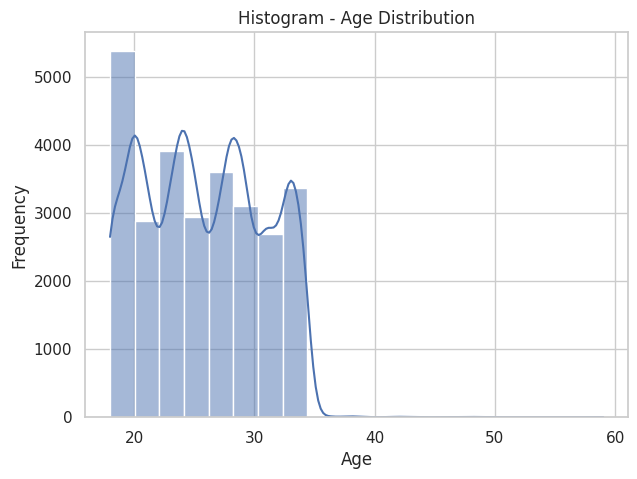

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.title('Histogram - Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

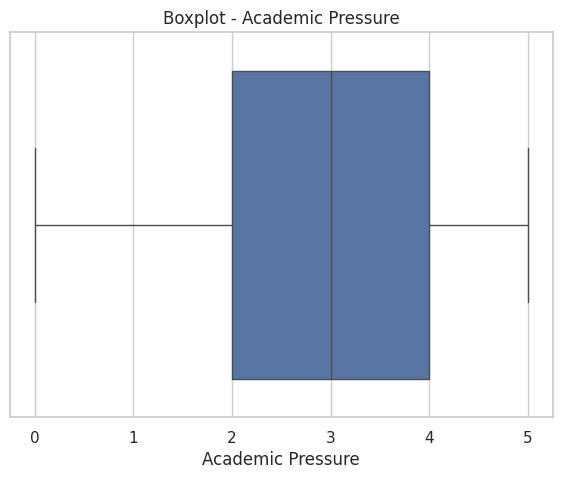

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Academic Pressure')
plt.title('Boxplot - Academic Pressure')
plt.xlabel('Academic Pressure')
plt.show()

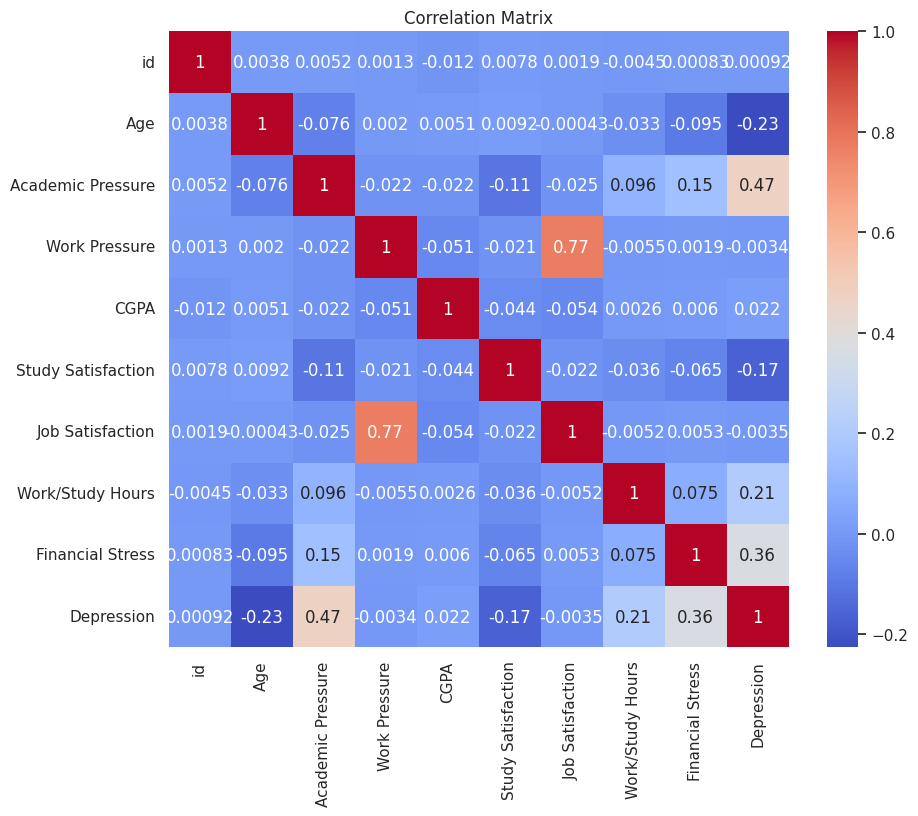

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


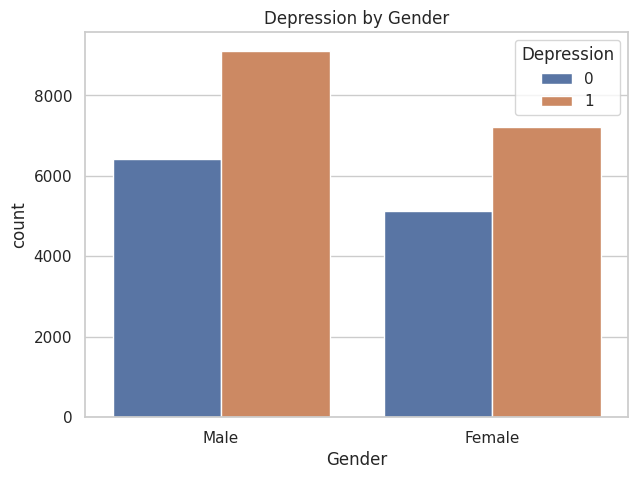

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender', hue='Depression')
plt.title('Depression by Gender')
plt.show()

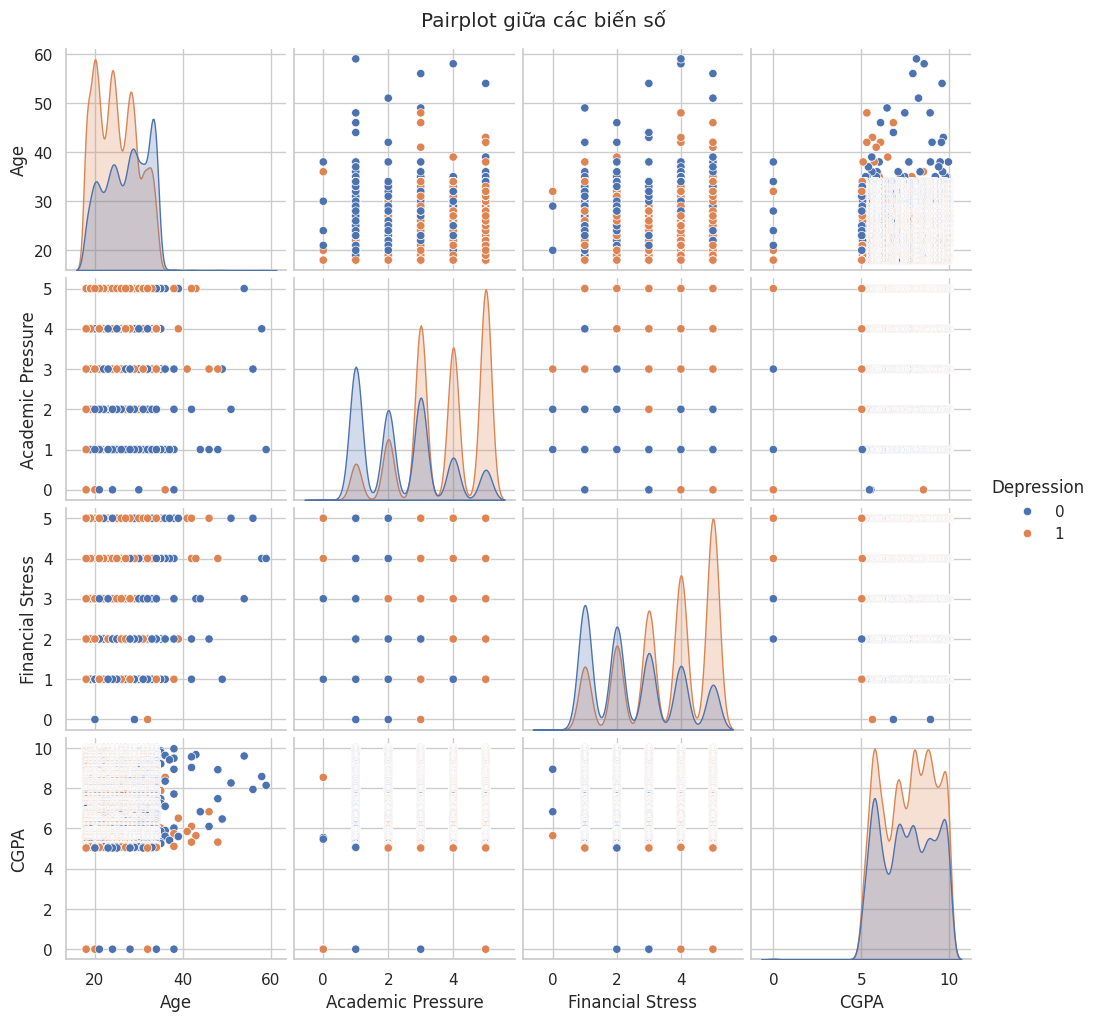

In [ ]:
numeric_cols = ['Age', 'Academic Pressure', 'Financial Stress', 'CGPA']
sns.pairplot(df[numeric_cols + ['Depression']], hue='Depression', diag_kind='kde')
plt.suptitle('Pairplot giữa các biến số', y=1.02)
plt.show()


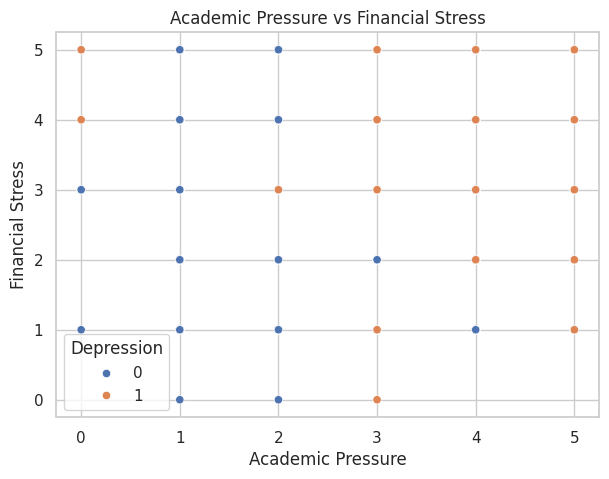

In [ ]:
# Scatter Plot giữa Academic Pressure và Financial Stress
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Academic Pressure', y='Financial Stress', hue='Depression')
plt.title('Academic Pressure vs Financial Stress')
plt.show()


In [ ]:
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4488,22499,Male,33.0,Patna,Student,4.0,0.0,10.0,1.0,0.0,Less than 5 hours,Moderate,BSc,Yes,8.0,5.0,No,1
14942,75373,Male,25.0,Srinagar,Student,5.0,0.0,10.0,5.0,0.0,5-6 hours,Healthy,M.Tech,Yes,4.0,4.0,Yes,0
3465,17340,Female,32.0,Kanpur,Student,5.0,0.0,10.0,2.0,0.0,7-8 hours,Healthy,BE,Yes,2.0,2.0,Yes,0
17038,86332,Male,26.0,Indore,Student,2.0,0.0,10.0,3.0,0.0,7-8 hours,Unhealthy,B.Com,Yes,1.0,4.0,Yes,1
6467,32401,Male,33.0,Patna,Student,4.0,0.0,10.0,3.0,0.0,More than 8 hours,Healthy,BSc,Yes,10.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21805,110097,Male,34.0,Pune,Student,1.0,0.0,0.0,5.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,10.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.0,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1


2.5.1


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.model_selection import train_test_split

df = df[['Academic Pressure', 'CGPA', 'Sleep Duration', 'Financial Stress', 'Depression']]
df = df.dropna()

df['High CGPA'] = df['CGPA'].apply(lambda x: 1 if x > 3.0 else 0)
df['High Stress'] = df['Financial Stress'].apply(lambda x: 1 if x > 3 else 0)
df['High Pressure'] = df['Academic Pressure'].apply(lambda x: 1 if x > 3 else 0)
df['Low Sleep'] = df['Sleep Duration'].isin(['Less than 5 hours', '5-6 hours']).astype(int)
df['Depressed'] = df['Depression'].apply(lambda x: 1 if x == 'Yes' else 0)

df_bin = df[['High CGPA', 'High Stress', 'High Pressure', 'Low Sleep', 'Depressed']]
df_d = df_bin.sample(frac=0.3, random_state=42)
freq_apriori = apriori(df_d, min_support=0.2, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric='confidence', min_threshold=0.6)
print("Tập luật (Apriori):")
print(rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Tập luật (Apriori):
                    antecedents  consequents   support  confidence      lift
0                 (High Stress)  (High CGPA)  0.442533     0.99973  1.000089
1               (High Pressure)  (High CGPA)  0.406093     1.00000  1.000359
2                   (Low Sleep)  (High CGPA)  0.518280     0.99977  1.000128
3  (High Stress, High Pressure)  (High CGPA)  0.205257     1.00000  1.000359
4      (High Stress, Low Sleep)  (High CGPA)  0.233333     1.00000  1.000359
5    (Low Sleep, High Pressure)  (High CGPA)  0.215412     1.00000  1.000359


2.5.2


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

df = df[['Academic Pressure', 'CGPA', 'Sleep Duration', 'Financial Stress', 'Depression']].dropna()

df['High CGPA'] = df['CGPA'].apply(lambda x: 1 if x > 3.0 else 0)
df['High Stress'] = df['Financial Stress'].apply(lambda x: 1 if x > 3 else 0)
df['High Pressure'] = df['Academic Pressure'].apply(lambda x: 1 if x > 3 else 0)
df['Low Sleep'] = df['Sleep Duration'].isin(['Less than 5 hours', '5-6 hours']).astype(int)
df['Depressed'] = df['Depression'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

df_bin = df[['High CGPA', 'High Stress', 'High Pressure', 'Low Sleep', 'Depressed']]

frequent_itemsets_apriori = apriori(df_bin, min_support=0.1, use_colnames=True)
rules_apriori = association_rules(frequent_itemsets_apriori, metric='confidence', min_threshold=0.6)

frequent_itemsets_fpgrowth = fpgrowth(df_bin, min_support=0.1, use_colnames=True)
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric='confidence', min_threshold=0.6)

def evaluate_rules(rules_df):
    rules_df['max_confidence'] = rules_df[['confidence', 'lift']].max(axis=1)
    return rules_df[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'max_confidence']]

rules_apriori_eval = evaluate_rules(rules_apriori)
rules_fpgrowth_eval = evaluate_rules(rules_fpgrowth)

print(" LUẬT TỪ APRIORI")
print(rules_apriori_eval.sort_values(by='lift', ascending=False).head())
print("\n LUẬT TỪ FPGROWTH")
print(rules_fpgrowth_eval.sort_values(by='lift', ascending=False).head())

 LUẬT TỪ APRIORI
                    antecedents  consequents   support  confidence      lift  \
1               (High Pressure)  (High CGPA)  0.410380    0.999913  1.000235   
5    (Low Sleep, High Pressure)  (High CGPA)  0.220924    0.999838  1.000160   
3  (High Stress, High Pressure)  (High CGPA)  0.206265    0.999826  1.000149   
4      (High Stress, Low Sleep)  (High CGPA)  0.232035    0.999691  1.000014   
0                 (High Stress)  (High CGPA)  0.447511    0.999680  1.000002   

   max_confidence  
1        1.000235  
5        1.000160  
3        1.000149  
4        1.000014  
0        1.000002  

 LUẬT TỪ FPGROWTH
                    antecedents  consequents   support  confidence      lift  \
3               (High Pressure)  (High CGPA)  0.410380    0.999913  1.000235   
4    (Low Sleep, High Pressure)  (High CGPA)  0.220924    0.999838  1.000160   
5  (High Stress, High Pressure)  (High CGPA)  0.206265    0.999826  1.000149   
2      (High Stress, Low Sleep)  (High CGPA


 LUẬT TỪ FPGROWTH
                    antecedents  consequents   support  confidence      lift  \
3               (High Pressure)  (High CGPA)  0.410380    0.999913  1.000235   
4    (Low Sleep, High Pressure)  (High CGPA)  0.220924    0.999838  1.000160   
5  (High Stress, High Pressure)  (High CGPA)  0.206265    0.999826  1.000149   
2      (High Stress, Low Sleep)  (High CGPA)  0.232035    0.999691  1.000014   
1                 (High Stress)  (High CGPA)  0.447511    0.999680  1.000002   

   max_confidence  
3        1.000235  
4        1.000160  
5        1.000149  
2        1.000014  
1        1.000002  


In [ ]:
df.to_csv(r'df1.csv', index=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag